#### Simple EDA on alerts_csv/*.txt files

In [151]:
import pandas as pd
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
import numpy as np

In [128]:
root = Path.cwd().parent.parent
sys.path.insert(0, str(root / "thesis"))

In [129]:
scenario = "harrison"

In [130]:
file_path = f'/Users/annavisman/stack/TUDelft/thesis/msc-thesis/data/alerts_csv/{scenario}_alerts.txt'

# Load the file into a DataFrame
df = pd.read_csv(file_path)

print(f"Label distribution for scenario {scenario}:")
print(df["time_label"].value_counts())

Label distribution for scenario harrison:
time_label
dirb                    416011
false_positive          162456
wpscan                    9709
dnsteal                   3239
cracking                  1256
service_scans              829
network_scans              296
privilege_escalation        94
webshell                    32
reverse_shell               20
service_stop                 6
Name: count, dtype: int64


In [131]:
df.head()

,time,name,ip,host,short,time_label,event_label
0,1643932807,Suricata: Alert - ET INFO Observed DNS Query t...,192.168.131.109,internal_share,S-Dns-Qry3,false_positive,dnsteal
1,1643932807,Wazuh: First time this IDS alert is generated.,192.168.131.109,internal_share,W-All-Ids,false_positive,-
2,1643932807,Wazuh: First time this IDS alert is generated.,192.168.128.1,inet-firewall,W-All-Ids,false_positive,-
3,1643932807,Suricata: Alert - ET INFO Observed DNS Query t...,192.168.128.1,inet-firewall,S-Dns-Qry3,false_positive,dnsteal
4,1643932819,Suricata: Alert - ET INFO Observed DNS Query t...,192.168.131.109,internal_share,S-Dns-Qry3,false_positive,dnsteal


##### 1) Create time windows of 2 seconds

In [132]:
def time_of_day_bucket(ts):
    if pd.isna(ts):
        return "unknown"
    h = ts.hour
    if 5 <= h < 10:
        return "morning"
    elif 10 <= h < 14:
        return "midday"
    elif 14 <= h < 18:
        return "afternoon"
    elif 18 <= h < 22:
        return "evening"
    else:
        return "night"

def build_labeled_window_transactions(
    df: pd.DataFrame,
    time_col: str = "time",
    detector_col: str = "short",
    host_col: str = "host",
    label_col: str = "time_label",
    benign_label: str = "false_positive",
    window_size_s: int = 2,
):
    out = df.copy()

    # Clean
    needed = [time_col, detector_col, host_col, label_col]
    out = out.dropna(subset=needed).copy()
    out[time_col] = pd.to_numeric(out[time_col], errors="coerce")
    out = out.dropna(subset=[time_col]).copy()
    out[time_col] = out[time_col].astype("int64")

    out["time_norm"] = pd.to_datetime(out[time_col], unit="s", utc=True, errors="coerce")
    out["time_of_day"] = out["time_norm"].apply(time_of_day_bucket)
    out["time_epoch"] = (out["time_norm"].astype("int64") // 10**9).astype("int64")
    # Window assignment
    out["window_start"] = (out[time_col] // window_size_s) * window_size_s
    out["window_end"] = out["window_start"] + window_size_s

    # Flat items
    out["detector_item"] = out[detector_col].astype(str)
    out["host_item"] = out[host_col].astype(str)

    def _label_window(labels: pd.Series) -> str:
        labels = set(labels.astype(str))
        has_benign = benign_label in labels
        has_attack = any(lbl != benign_label for lbl in labels)

        if has_attack and has_benign:
            return "mixed"
        elif has_attack:
            return "attack"
        else:
            return "benign"
        
    # print the min and max time_norm stamps for debugging
    print(f"Min time_norm: {out['time_norm'].min()}")
    print(f"Max time_norm: {out['time_norm'].max()}")

    tx = (
        out.groupby(["window_start", "window_end"], sort=True)
        .apply(
            lambda g: pd.Series({
                "n_alerts": len(g),
                "items": set(g["detector_item"]).union(set(g["host_item"])),
                "alert_labels": set(g[label_col].astype(str)),
                "tx_label": _label_window(g[label_col]),
                "time_of_day": g["time_of_day"].mode().iloc[0] if not g["time_of_day"].mode().empty else "unknown",
            })
        )
        .reset_index()
    )

    return tx

##### 2) Represent each alert as items

In [133]:
transactions = build_labeled_window_transactions(
    df,
    window_size_s=2,
)

transactions.to_csv(f'{scenario}_transactions.csv', index=False)

Min time_norm: 2022-02-04 00:00:01+00:00
Max time_norm: 2022-02-08 23:59:46+00:00


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_61257/566688561.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


##### 3) Split data using the labels

In [134]:
benign_transactions = transactions[transactions["tx_label"] == "benign"].copy()
attack_transactions = transactions[transactions["tx_label"] == "attack"].copy()
mixed_transactions  = transactions[transactions["tx_label"] == "mixed"].copy()
print(transactions["tx_label"].value_counts())

tx_label
benign    32908
attack     1686
Name: count, dtype: int64


In [135]:
benign_transactions.to_csv(f'{scenario}_benign_transactions.csv', index=False)
attack_transactions.to_csv(f'{scenario}_attack_transactions.csv', index=False)

##### 4) Measure co-occurrence strength

##### Transaction size

In [136]:
tx = transactions.copy()

tx["tx_size"] = tx["items"].apply(len)

# Summary stats per class
size_summary = tx.groupby("tx_label")["tx_size"].describe()
print(size_summary)

size_counts = (
    tx.groupby(["tx_label", "tx_size"])
      .size()
      .reset_index(name="count")
      .sort_values(["tx_label", "tx_size"])
)

            count      mean       std  min  25%  50%  75%   max
tx_label                                                       
attack     1686.0  4.260973  2.332479  2.0  2.0  4.0  5.0  17.0
benign    32908.0  3.768810  1.137106  2.0  4.0  4.0  4.0  10.0


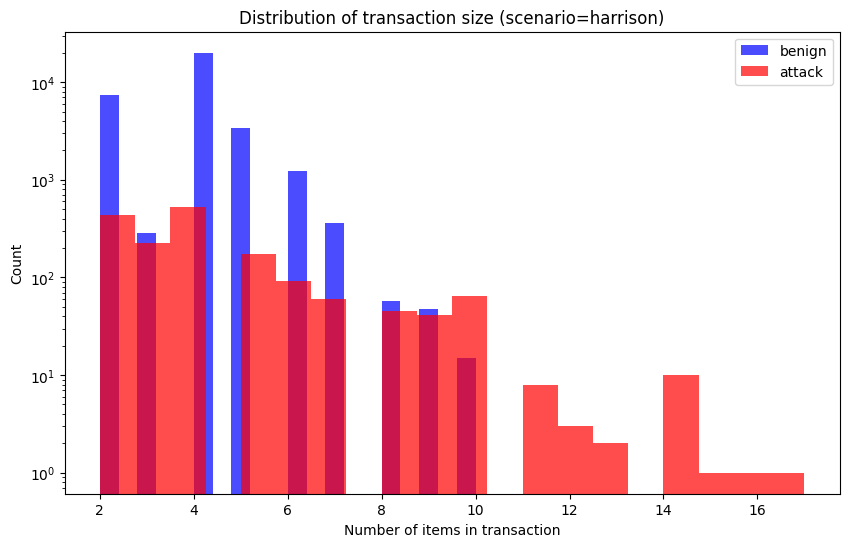

In [137]:
plt.figure(figsize=(10, 6))

colors = {"benign": "blue", "attack": "red"}

for label in ["benign", "attack"]:
    subset = tx.loc[tx["tx_label"] == label, "tx_size"]
    plt.hist(subset, bins=20, alpha=0.7, color=colors[label], label=label)

plt.title(f"Distribution of transaction size (scenario={scenario})")
plt.xlabel("Number of items in transaction")
plt.ylabel("Count")
plt.yscale("log")
plt.legend()
plt.show()

#### Time of day

In [138]:
tx = transactions.copy()
tx["tx_size"] = tx["items"].apply(len)

# # 1) co-occurrence counts by time_of_day + label
# time_label_counts = (
#     tx.groupby(["time_of_day", "tx_label"])
#       .size()
#       .reset_index(name="count")
#       .sort_values(["time_of_day", "tx_label"])
# )
# print(time_label_counts)

# 2) tx_size summary by time_of_day + label
time_label_size_summary = (
    tx.groupby(["time_of_day", "tx_label"])["tx_size"]
      .describe()
      .reset_index()
)
print(time_label_size_summary)

  time_of_day tx_label   count      mean       std  min  25%  50%  75%   max
0   afternoon   benign  6204.0  3.615248  1.285254  2.0  2.0  4.0  4.0  10.0
1     evening   benign  4153.0  3.998555  0.823837  2.0  4.0  4.0  4.0  10.0
2      midday   attack   301.0  2.584718  1.207048  2.0  2.0  2.0  2.0   7.0
3      midday   benign  7192.0  3.489989  1.386070  2.0  2.0  4.0  4.0  10.0
4     morning   attack  1385.0  4.625271  2.358804  2.0  3.0  4.0  5.0  17.0
5     morning   benign  7656.0  3.733673  1.231418  2.0  2.0  4.0  4.0  10.0
6       night   benign  7703.0  4.063871  0.564759  2.0  4.0  4.0  4.0   9.0


##### Pair frequency

In [139]:
def count_pair_frequency(df: pd.DataFrame, items_col: str = "items") -> pd.DataFrame:
    pair_counter = Counter()

    for items in df[items_col]:
        items = sorted(set(items))
        for pair in combinations(items, 2):
            pair_counter[pair] += 1

    out = pd.DataFrame(
        [{"pair": pair, "pair_count": count} for pair, count in pair_counter.items()]
    ).sort_values("pair_count", ascending=False)

    return out.reset_index(drop=True)

In [140]:
pair_freq_all = count_pair_frequency(tx)
pair_freq_all.to_csv(f'{scenario}_pair_frequencies.csv', index=False)
print(pair_freq_all.head(20))

                               pair  pair_count
0        (W-All-Evt, inet-firewall)       24418
1           (S-Dns-Qry3, W-All-Evt)       23576
2       (W-All-Evt, internal_share)       23572
3       (S-Dns-Qry3, inet-firewall)       23558
4      (S-Dns-Qry3, internal_share)       23558
5   (inet-firewall, internal_share)       23553
6           (W-Sys-Dov, smith_mail)        3540
7                 (W-Sys-Dov, mail)        3412
8           (W-All-Evt, W-All-Mul1)        3250
9       (W-All-Mul1, inet-firewall)        3225
10     (W-All-Mul1, internal_share)        3115
11         (S-Dns-Qry3, W-All-Mul1)        3113
12           (S-Tls-Rec, W-All-Evt)        2273
13           (S-Tls-Hnd, S-Tls-Rec)        2272
14           (S-Tls-Hnd, W-All-Evt)        2271
15         (W-Sys-Dov, taylor_mail)        1661
16           (W-All-Evt, webserver)        1345
17           (S-Tls-Rec, webserver)        1338
18           (S-Tls-Hnd, webserver)        1337
19           (W-All-Evt, W-Sys-Dov)     

In [141]:
pair_freq_benign = count_pair_frequency(benign_transactions)
pair_freq_benign.to_csv(f'{scenario}_benign_pair_frequencies.csv', index=False)
print(pair_freq_benign.head(20))

                               pair  pair_count
0        (W-All-Evt, inet-firewall)       23984
1           (S-Dns-Qry3, W-All-Evt)       23224
2       (W-All-Evt, internal_share)       23220
3       (S-Dns-Qry3, inet-firewall)       23206
4      (S-Dns-Qry3, internal_share)       23206
5   (inet-firewall, internal_share)       23201
6           (W-Sys-Dov, smith_mail)        3401
7           (W-All-Evt, W-All-Mul1)        3202
8       (W-All-Mul1, inet-firewall)        3178
9                 (W-Sys-Dov, mail)        3163
10     (W-All-Mul1, internal_share)        3082
11         (S-Dns-Qry3, W-All-Mul1)        3080
12           (S-Tls-Hnd, S-Tls-Rec)        2089
13           (S-Tls-Rec, W-All-Evt)        2088
14           (S-Tls-Hnd, W-All-Evt)        2088
15         (W-Sys-Dov, taylor_mail)        1524
16           (W-All-Evt, webserver)        1250
17           (S-Tls-Rec, webserver)        1243
18           (S-Tls-Hnd, webserver)        1243
19           (W-All-Evt, W-Sys-Dov)     

In [142]:
pair_freq_attack= count_pair_frequency(attack_transactions)
pair_freq_attack.to_csv(f'{scenario}_attack_pair_frequencies.csv', index=False)
print(pair_freq_attack.head(20))

                               pair  pair_count
0      (W-Acc-400, intranet_server)         812
1           (W-Acc-400, W-All-Mul3)         807
2     (W-All-Mul3, intranet_server)         807
3        (W-All-Evt, inet-firewall)         434
4      (A-All-Evt, intranet_server)         384
5            (A-All-Evt, W-Acc-400)         380
6           (A-All-Evt, W-All-Mul3)         374
7   (inet-firewall, internal_share)         352
8       (W-All-Evt, internal_share)         352
9      (S-Dns-Qry3, internal_share)         352
10      (S-Dns-Qry3, inet-firewall)         352
11          (S-Dns-Qry3, W-All-Evt)         352
12                (W-Sys-Dov, mail)         249
13          (A-Acc-Chr2, W-Acc-400)         202
14         (A-Acc-Chr2, W-All-Mul3)         202
15    (A-Acc-Chr2, intranet_server)         202
16           (W-Acc-400, W-Acc-Sus)         186
17          (W-Acc-Sus, W-All-Mul3)         186
18     (W-Acc-Sus, intranet_server)         186
19           (S-Tls-Rec, W-All-Evt)     

In [143]:
intersection = pd.merge(
    pair_freq_benign.rename(columns={"pair_count": "benign_count"}),
    pair_freq_attack.rename(columns={"pair_count": "attack_count"}),
    on="pair",
    how="inner",
).fillna(0)

In [144]:
intersection.head(20)
intersection.to_csv(f'{scenario}_pair_frequency_intersection.csv', index=False)

In [145]:
# compare the total number of pairs existing with the number of pairs that exist in both classes
total_pairs = len(pair_freq_all)
intersection_pairs = len(intersection)
print(f"Total unique pairs: {total_pairs}")
print(f"Pairs in both classes: {intersection_pairs}")
print(f"Percentage of pairs in both classes: {intersection_pairs / total_pairs:.2%}")

Total unique pairs: 817
Pairs in both classes: 197
Percentage of pairs in both classes: 24.11%


In [146]:
pair_compare = (
    pair_freq_attack.rename(columns={"pair_count": "attack_count"})
    .merge(
        pair_freq_benign.rename(columns={"pair_count": "benign_count"}),
        on="pair",
        how="outer"
    )
    .fillna(0)
)

pair_compare["attack_count"] = pair_compare["attack_count"].astype(int)
pair_compare["benign_count"] = pair_compare["benign_count"].astype(int)
pair_compare["total_count"] = pair_compare["attack_count"] + pair_compare["benign_count"]

pair_compare = pair_compare.sort_values(
    ["attack_count", "total_count"], ascending=False
).reset_index(drop=True)

print(pair_compare.head(30))

                               pair  attack_count  benign_count  total_count
0      (W-Acc-400, intranet_server)           812             0          812
1           (W-Acc-400, W-All-Mul3)           807             0          807
2     (W-All-Mul3, intranet_server)           807             0          807
3        (W-All-Evt, inet-firewall)           434         23984        24418
4      (A-All-Evt, intranet_server)           384             1          385
5            (A-All-Evt, W-Acc-400)           380             0          380
6           (A-All-Evt, W-All-Mul3)           374             0          374
7           (S-Dns-Qry3, W-All-Evt)           352         23224        23576
8       (W-All-Evt, internal_share)           352         23220        23572
9       (S-Dns-Qry3, inet-firewall)           352         23206        23558
10     (S-Dns-Qry3, internal_share)           352         23206        23558
11  (inet-firewall, internal_share)           352         23201        23553

##### Pattern consistency

In [147]:
# def support(df: pd.DataFrame, pattern: set, items_col: str = "items") -> float:
#     if len(df) == 0:
#         return 0.0
#     return df[items_col].apply(lambda items: pattern.issubset(items)).mean()


# def pattern_metrics(
#     tx: pd.DataFrame,
#     pattern: set,
#     items_col: str = "items",
#     label_col: str = "tx_label"
# ) -> dict:
#     attack_df = tx[tx[label_col] == "attack"]
#     benign_df = tx[tx[label_col] == "benign"]

#     supp_attack = support(attack_df, pattern, items_col)
#     supp_benign = support(benign_df, pattern, items_col)

#     denom = supp_attack + supp_benign
#     conf_attack = supp_attack / denom if denom > 0 else 0.0
#     conf_benign = supp_benign / denom if denom > 0 else 0.0

#     return {
#         "pattern": tuple(sorted(pattern)),
#         "support_attack": supp_attack,
#         "support_benign": supp_benign,
#         "confidence_attack": conf_attack,
#         "confidence_benign": conf_benign,
#     }

In [148]:
def all_pair_metrics(
    tx: pd.DataFrame,
    items_col: str = "items",
    label_col: str = "tx_label",
    min_total_count: int = 1
) -> pd.DataFrame:
    attack_df = tx[tx[label_col] == "attack"]
    benign_df = tx[tx[label_col] == "benign"]

    # Count pairs in each class
    attack_pairs = count_pair_frequency(attack_df, items_col).rename(columns={"pair_count": "attack_count"})
    benign_pairs = count_pair_frequency(benign_df, items_col).rename(columns={"pair_count": "benign_count"})

    pair_df = (
        attack_pairs.merge(benign_pairs, on="pair", how="outer")
        .fillna(0)
    )

    pair_df["attack_count"] = pair_df["attack_count"].astype(int)
    pair_df["benign_count"] = pair_df["benign_count"].astype(int)
    pair_df["total_count"] = pair_df["attack_count"] + pair_df["benign_count"]

    n_attack = len(attack_df)
    n_benign = len(benign_df)

    pair_df["support_attack"] = pair_df["attack_count"] / n_attack if n_attack else 0.0
    pair_df["support_benign"] = pair_df["benign_count"] / n_benign if n_benign else 0.0

    denom = pair_df["support_attack"] + pair_df["support_benign"]
    pair_df["confidence_attack"] = pair_df["support_attack"] / denom.replace(0, pd.NA)
    pair_df["confidence_benign"] = pair_df["support_benign"] / denom.replace(0, pd.NA)

    pair_df["confidence_attack"] = pair_df["confidence_attack"].fillna(0.0)
    pair_df["confidence_benign"] = pair_df["confidence_benign"].fillna(0.0)

    pair_df = pair_df[pair_df["total_count"] >= min_total_count].copy()

    return pair_df.sort_values(
        ["confidence_attack", "support_attack", "total_count"],
        ascending=False
    ).reset_index(drop=True)

In [149]:
pair_metrics_df = all_pair_metrics(tx)
pair_metrics_df.to_csv(f'{scenario}_pair_metrics.csv', index=False)
print(pair_metrics_df.head(30))

                             pair  attack_count  benign_count  total_count  \
0    (W-Acc-400, intranet_server)           812             0          812   
1         (W-Acc-400, W-All-Mul3)           807             0          807   
2   (W-All-Mul3, intranet_server)           807             0          807   
3          (A-All-Evt, W-Acc-400)           380             0          380   
4         (A-All-Evt, W-All-Mul3)           374             0          374   
5         (A-Acc-Chr2, W-Acc-400)           202             0          202   
6        (A-Acc-Chr2, W-All-Mul3)           202             0          202   
7          (W-Acc-400, W-Acc-Sus)           186             0          186   
8         (W-Acc-Sus, W-All-Mul3)           186             0          186   
9    (W-Acc-Sus, intranet_server)           186             0          186   
10         (W-Acc-400, W-Acc-Att)           184             0          184   
11        (W-Acc-Att, W-All-Mul3)           184             0   

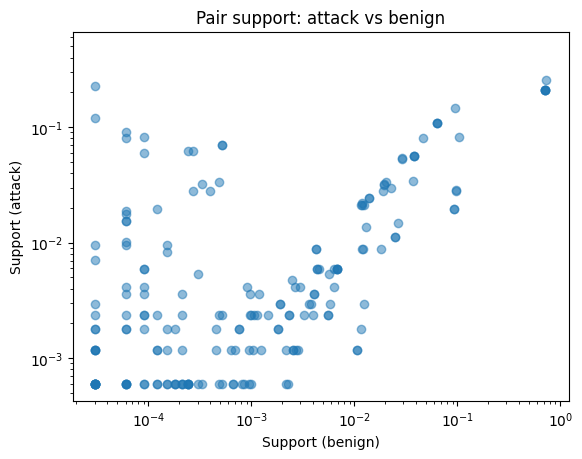

In [150]:
df = pair_metrics_df.copy()

plt.figure()

plt.scatter(
    df["support_benign"],
    df["support_attack"],
    alpha=0.5
)

plt.yscale("log")
plt.xscale("log")
plt.xlabel("Support (benign)")
plt.ylabel("Support (attack)")
plt.title("Pair support: attack vs benign")

plt.show()

##### TFIDF

In [152]:
def compute_pair_tfidf_by_class(
    pair_df: pd.DataFrame,
    n_attack_windows: int,
    n_benign_windows: int,
) -> pd.DataFrame:
    """
    Compute class-aware TF-IDF-like scores for pairs.

    Expected columns:
      - pair
      - attack_count
      - benign_count

    Interpretation:
      tf_attack  = fraction of attack windows containing the pair
      idf_global = penalizes pairs common across both classes/windows
      tfidf_attack = attack-specific importance

    Returns added columns:
      - tf_attack
      - tf_benign
      - window_frequency
      - idf_global
      - tfidf_attack
      - tfidf_benign
    """
    df = pair_df.copy()

    N = n_attack_windows + n_benign_windows
    df["window_frequency"] = df["attack_count"] + df["benign_count"]

    df["tf_attack"] = df["attack_count"] / max(n_attack_windows, 1)
    df["tf_benign"] = df["benign_count"] / max(n_benign_windows, 1)

    df["idf_global"] = np.log((N + 1) / (1 + df["window_frequency"]))
    df["idf_global"] = df["idf_global"].clip(lower=0)

    df["tfidf_attack"] = df["tf_attack"] * df["idf_global"]
    df["tfidf_benign"] = df["tf_benign"] * df["idf_global"]

    return df

In [156]:
n_attack_windows = len(attack_transactions)
n_benign_windows = len(benign_transactions)

pair_tfidf = compute_pair_tfidf_by_class(
    pair_df=pair_metrics_df[["pair", "attack_count", "benign_count"]].copy(),
    n_attack_windows=n_attack_windows,
    n_benign_windows=n_benign_windows,
)

#### best attack pairs (TFIDF relative to attack class)

In [157]:
pair_tfidf.sort_values("tfidf_attack", ascending=False).head(30)

,pair,attack_count,benign_count,window_frequency,tf_attack,tf_benign,idf_global,tfidf_attack,tfidf_benign
0,"(W-Acc-400, intranet_server)",812,0,812,0.481613,0.000000,3.750733,1.806403,0.000000
2,"(W-All-Mul3, intranet_server)",807,0,807,0.478648,0.000000,3.756902,1.798233,0.000000
1,"(W-Acc-400, W-All-Mul3)",807,0,807,0.478648,0.000000,3.756902,1.798233,0.000000
263,"(A-All-Evt, intranet_server)",384,1,385,0.227758,0.000030,4.495627,1.023915,0.000137
3,"(A-All-Evt, W-Acc-400)",380,0,380,0.225386,0.000000,4.508665,1.016188,0.000000
4,"(A-All-Evt, W-All-Mul3)",374,0,374,0.221827,0.000000,4.524538,1.003664,0.000000
5,"(A-Acc-Chr2, W-Acc-400)",202,0,202,0.119810,0.000000,5.138258,0.615616,0.000000
6,"(A-Acc-Chr2, W-All-Mul3)",202,0,202,0.119810,0.000000,5.138258,0.615616,0.000000
264,"(A-Acc-Chr2, intranet_server)",202,1,203,0.119810,0.000030,5.133344,0.615027,0.000156
9,"(W-Acc-Sus, intranet_server)",186,0,186,0.110320,0.000000,5.220356,0.575911,0.000000


#### best attack pairs (TFIDF relative to attack class)

In [155]:
pair_tfidf.sort_values("tfidf_benign", ascending=False).head(30)

,pair,attack_count,benign_count,window_frequency,tf_attack,tf_benign,idf_global,tfidf_attack,tfidf_benign
445,"(inet-firewall, internal_share)",352,23201,23553,0.208778,0.705026,0.384414,0.080257,0.271022
447,"(S-Dns-Qry3, internal_share)",352,23206,23558,0.208778,0.705178,0.384201,0.080213,0.270930
446,"(S-Dns-Qry3, inet-firewall)",352,23206,23558,0.208778,0.705178,0.384201,0.080213,0.270930
448,"(W-All-Evt, internal_share)",352,23220,23572,0.208778,0.705604,0.383607,0.080089,0.270675
449,"(S-Dns-Qry3, W-All-Evt)",352,23224,23576,0.208778,0.705725,0.383438,0.080053,0.270601
444,"(W-All-Evt, inet-firewall)",434,23984,24418,0.257414,0.728820,0.348348,0.089670,0.253883
421,"(W-Sys-Dov, smith_mail)",139,3401,3540,0.082444,0.103349,2.279300,0.187914,0.235563
450,"(W-All-Evt, W-All-Mul1)",48,3202,3250,0.028470,0.097302,2.364747,0.067324,0.230094
451,"(W-All-Mul1, inet-firewall)",47,3178,3225,0.027877,0.096572,2.372466,0.066136,0.229114
456,"(W-All-Mul1, internal_share)",33,3082,3115,0.019573,0.093655,2.407159,0.047115,0.225443
